### Calculating and plotting correlation coeffcients 

In [1]:
import mne
import numpy as np
from glob import glob
from osl_dynamics.utils import plotting
import random 
import matplotlib.pyplot as plt
import scipy as scipy

In [3]:
#CALCULATING SESSION TRIAL TIMECOURSE AVERAGES FOR OPM SESSIONS 

#GETTING OPM STC FILES -------------------------------------------------------------------------------------------------
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
hmm_dir = f"{deriv}/hmm_8state_opms"
files = sorted(
    f for f in glob(f"{hmm_dir}/stc/*stc-raw.fif")
    if "ses-001" in f or "ses-002" in f
)

raw = []
for file in files: 
    rawfile = mne.io.read_raw_fif(file)
    raw.append(rawfile)

#GETTING EVENTS FOR EVENTS FILE --------------------------------------------------------------------------------------------
events_list = []

for raw_ses in raw:
    left_events = mne.find_events(raw_ses, stim_channel='Lef')
    right_events = mne.find_events(raw_ses, stim_channel='Rig')
    events = np.concatenate([left_events, right_events], axis=0)
    events = events[np.argsort(events[:, 0])]
    events_list.append(events)
event_id = {'Lef': 3, 'Rig': 3}

# CREATING EPOCHS FOR THE TRIALS ------------------------------------------------------------------------------------------
epochs_list = [] 
for idx, raw_obj in enumerate(raw):
    epochs = mne.Epochs(
        raw_obj,
        events=events_list[idx],
        event_id=event_id,
        tmin=0,
        tmax=14,
        baseline=None,
        reject_by_annotation=True,
    )
    epochs_list.append(epochs)

print('epochs_list done')

alp_epochs_list = []
for epoch in epochs_list: 
    ses_epoch = epoch.get_data(picks='misc')
    alp_epochs_list.append(ses_epoch)  
alp_epochs_list_T = [arr.swapaxes(1, 2) for arr in alp_epochs_list]
print(alp_epochs_list_T[0].shape)

print('alp_epochs_list done')

# MEANING OVER TRIALS TO GET TRIAL TIMECOURSE ----------------------------------------------------------------------------------
alp_meaned_list = []
for ses in range(0,30):
    alp_epochs_meaned = np.mean(alp_epochs_list_T[ses], axis=0)
    alp_meaned_list.append(alp_epochs_meaned)

print('alp_meaned_list done')

Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-001_ses-001_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 359252 =      0.000 ...  1437.008 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-001_ses-002_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 363306 =      0.000 ...  1453.224 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-002_ses-001_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 328319 =      0.000 ...  1313.276 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_opms/stc/sub-002_ses-002_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 328106 =      0.000 ...  1312.424 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042

In [4]:
#CALCULATING SESSION TRIAL TIMECOURSE AVERAGES FOR SQUID SESSIONS 

#GETTING SQUID STC FILES -------------------------------------------------------------------------------------------------
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
hmm_dir = f"{deriv}/hmm_8state_squids"
files_SQUID = sorted(
    f for f in glob(f"{hmm_dir}/stc/*stc-raw.fif")
    if "ses-003" in f or "ses-004" in f
)

raw_SQUID = []
for file in files_SQUID: 
    rawfile = mne.io.read_raw_fif(file)
    raw_SQUID.append(rawfile)

#GETTING EVENTS FOR EVENTS FILE --------------------------------------------------------------------------------------------
events_list_SQUID = []

#For SQUIDS
for raw_ses in raw_SQUID:
    left_events = mne.find_events(raw_ses, stim_channel='Left_trial')
    left_events[:, 2][left_events[:, 2] == 1] = 2
    right_events = mne.find_events(raw_ses, stim_channel='Right_trial')
    right_events[:, 2][right_events[:, 2] == 1] = 3
    events = np.concatenate([left_events, right_events], axis=0)
    events = events[np.argsort(events[:, 0])]
    events_list_SQUID.append(events)
event_id_SQUID = {'Left_trial': 2, 'Right_trial': 3}

# CREATING EPOCHS FOR THE TRIALS ------------------------------------------------------------------------------------------
epochs_list_SQUID = [] 
for idx, raw_obj in enumerate(raw_SQUID):
    epochs_SQUID = mne.Epochs(
        raw_obj,
        events=events_list_SQUID[idx],
        event_id=event_id_SQUID,
        tmin=0,
        tmax=14,
        baseline=None,
        reject_by_annotation=True,
    )
    epochs_list_SQUID.append(epochs_SQUID)

print('epochs_list done')

alp_epochs_list_SQUID = []
for epoch in epochs_list_SQUID: 
    ses_epoch = epoch.get_data(picks='misc')
    alp_epochs_list_SQUID.append(ses_epoch)  
alp_epochs_list_T_SQUID = [arr.swapaxes(1, 2) for arr in alp_epochs_list_SQUID]
print(alp_epochs_list_T_SQUID[0].shape)

print('alp_epochs_list done')

# MEANING OVER TRIALS TO GET TRIAL TIMECOURSE ----------------------------------------------------------------------------------
alp_meaned_list_SQUID = []
for ses in range(0,30):
    alp_epochs_meaned_SQUID = np.mean(alp_epochs_list_T_SQUID[ses], axis=0)
    alp_meaned_list_SQUID.append(alp_epochs_meaned_SQUID)

print('alp_meaned_list done')

Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_squids/stc/sub-001_ses-003_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_squids/stc/sub-001_ses-004_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_squids/stc/sub-002_ses-003_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/hmm_8state_squids/stc/sub-002_ses-004_task-braille_run-001_stc-raw.fif...
    Range : 0 ... 337499 =      0.000 ...  1349.996 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_an

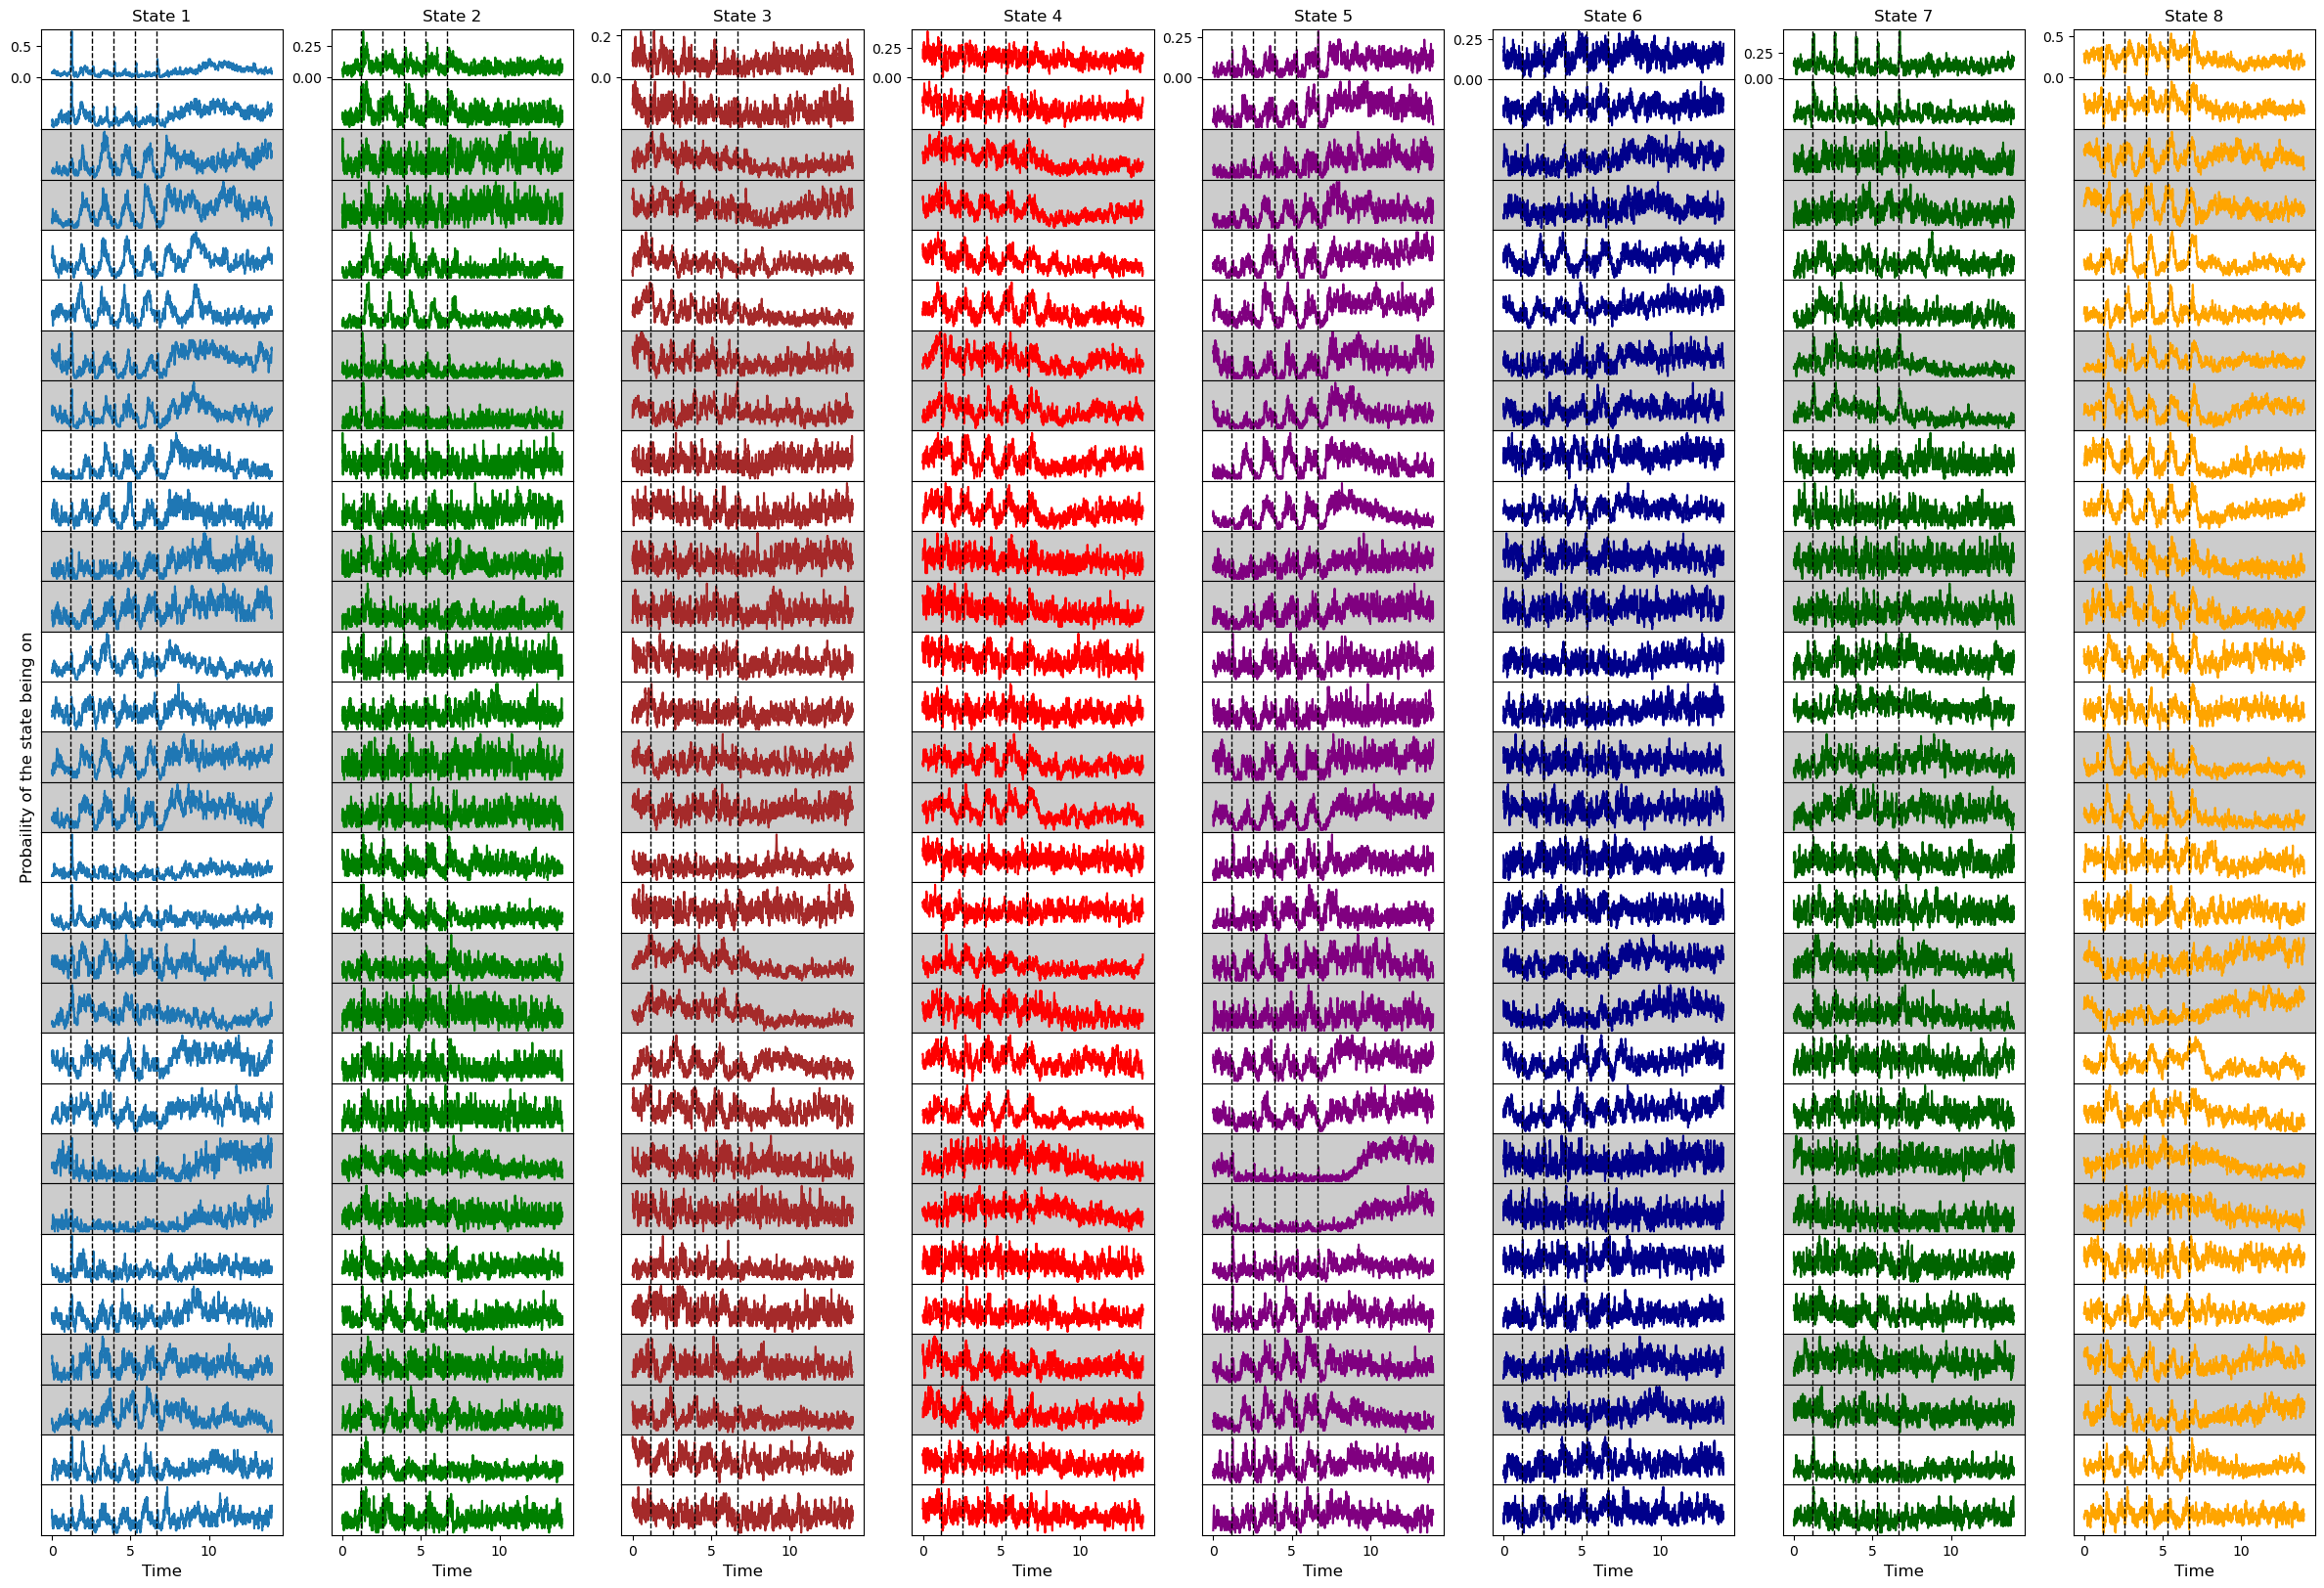

In [5]:
#PLOTTING OPM STATE TRIAL TIMECOURSES
no_sessions = 30
fig, axs = plt.subplots(no_sessions, 8) #, sharey=True)
fig.set_size_inches(30,20)
fig.subplots_adjust(hspace=0)
 
time = np.linspace(0, 14, 3501)
 
for ses in range(0, no_sessions):
    axs[ses, 0].plot(time,alp_meaned_list[ses][:,0])
    axs[ses, 1].plot(time,alp_meaned_list[ses][:,1], 'g')
    axs[ses, 2].plot(time,alp_meaned_list[ses][:,2], 'brown')
    axs[ses, 3].plot(time,alp_meaned_list[ses][:,3], 'r')
    axs[ses, 4].plot(time,alp_meaned_list[ses][:,4], 'purple')
    axs[ses, 5].plot(time,alp_meaned_list[ses][:,5], 'darkblue')
    axs[ses, 6].plot(time,alp_meaned_list[ses][:,6], 'darkgreen')
    axs[ses, 7].plot(time,alp_meaned_list[ses][:,7], 'orange')
 
#times where you want vertical dashed lines
vlines_times = [1.17, 2.54, 3.91, 5.28, 6.65]
 
for col in range(0,8):
    for row, ax in enumerate(axs[:, col]):
        for t in vlines_times:
            ax.axvline(
                x=t,
                color='black',
                linestyle='--',
                linewidth=1  # thin line
            )
 
        if row != 0:
                ax.tick_params(labelleft=False)
                ax.set_yticks([])
        if row == 14 and col == 0:
             ax.set_ylabel('Probaility of the state being on', size = 'large')
       
        if row == 0:
             ax.set_title('State ' + str(col + 1))
       
        if row == 29:
             ax.set_xlabel('Time', size='large')
   
for row in range(no_sessions):
    # integer divide by 2 → row pairs (0–1, 2–3, 4–5, ...)
    # % 2 toggles every pair
    if (row // 2) % 2 == 1:
        for col in range(8):
            axs[row, col].set_facecolor('0.80')  # light grey

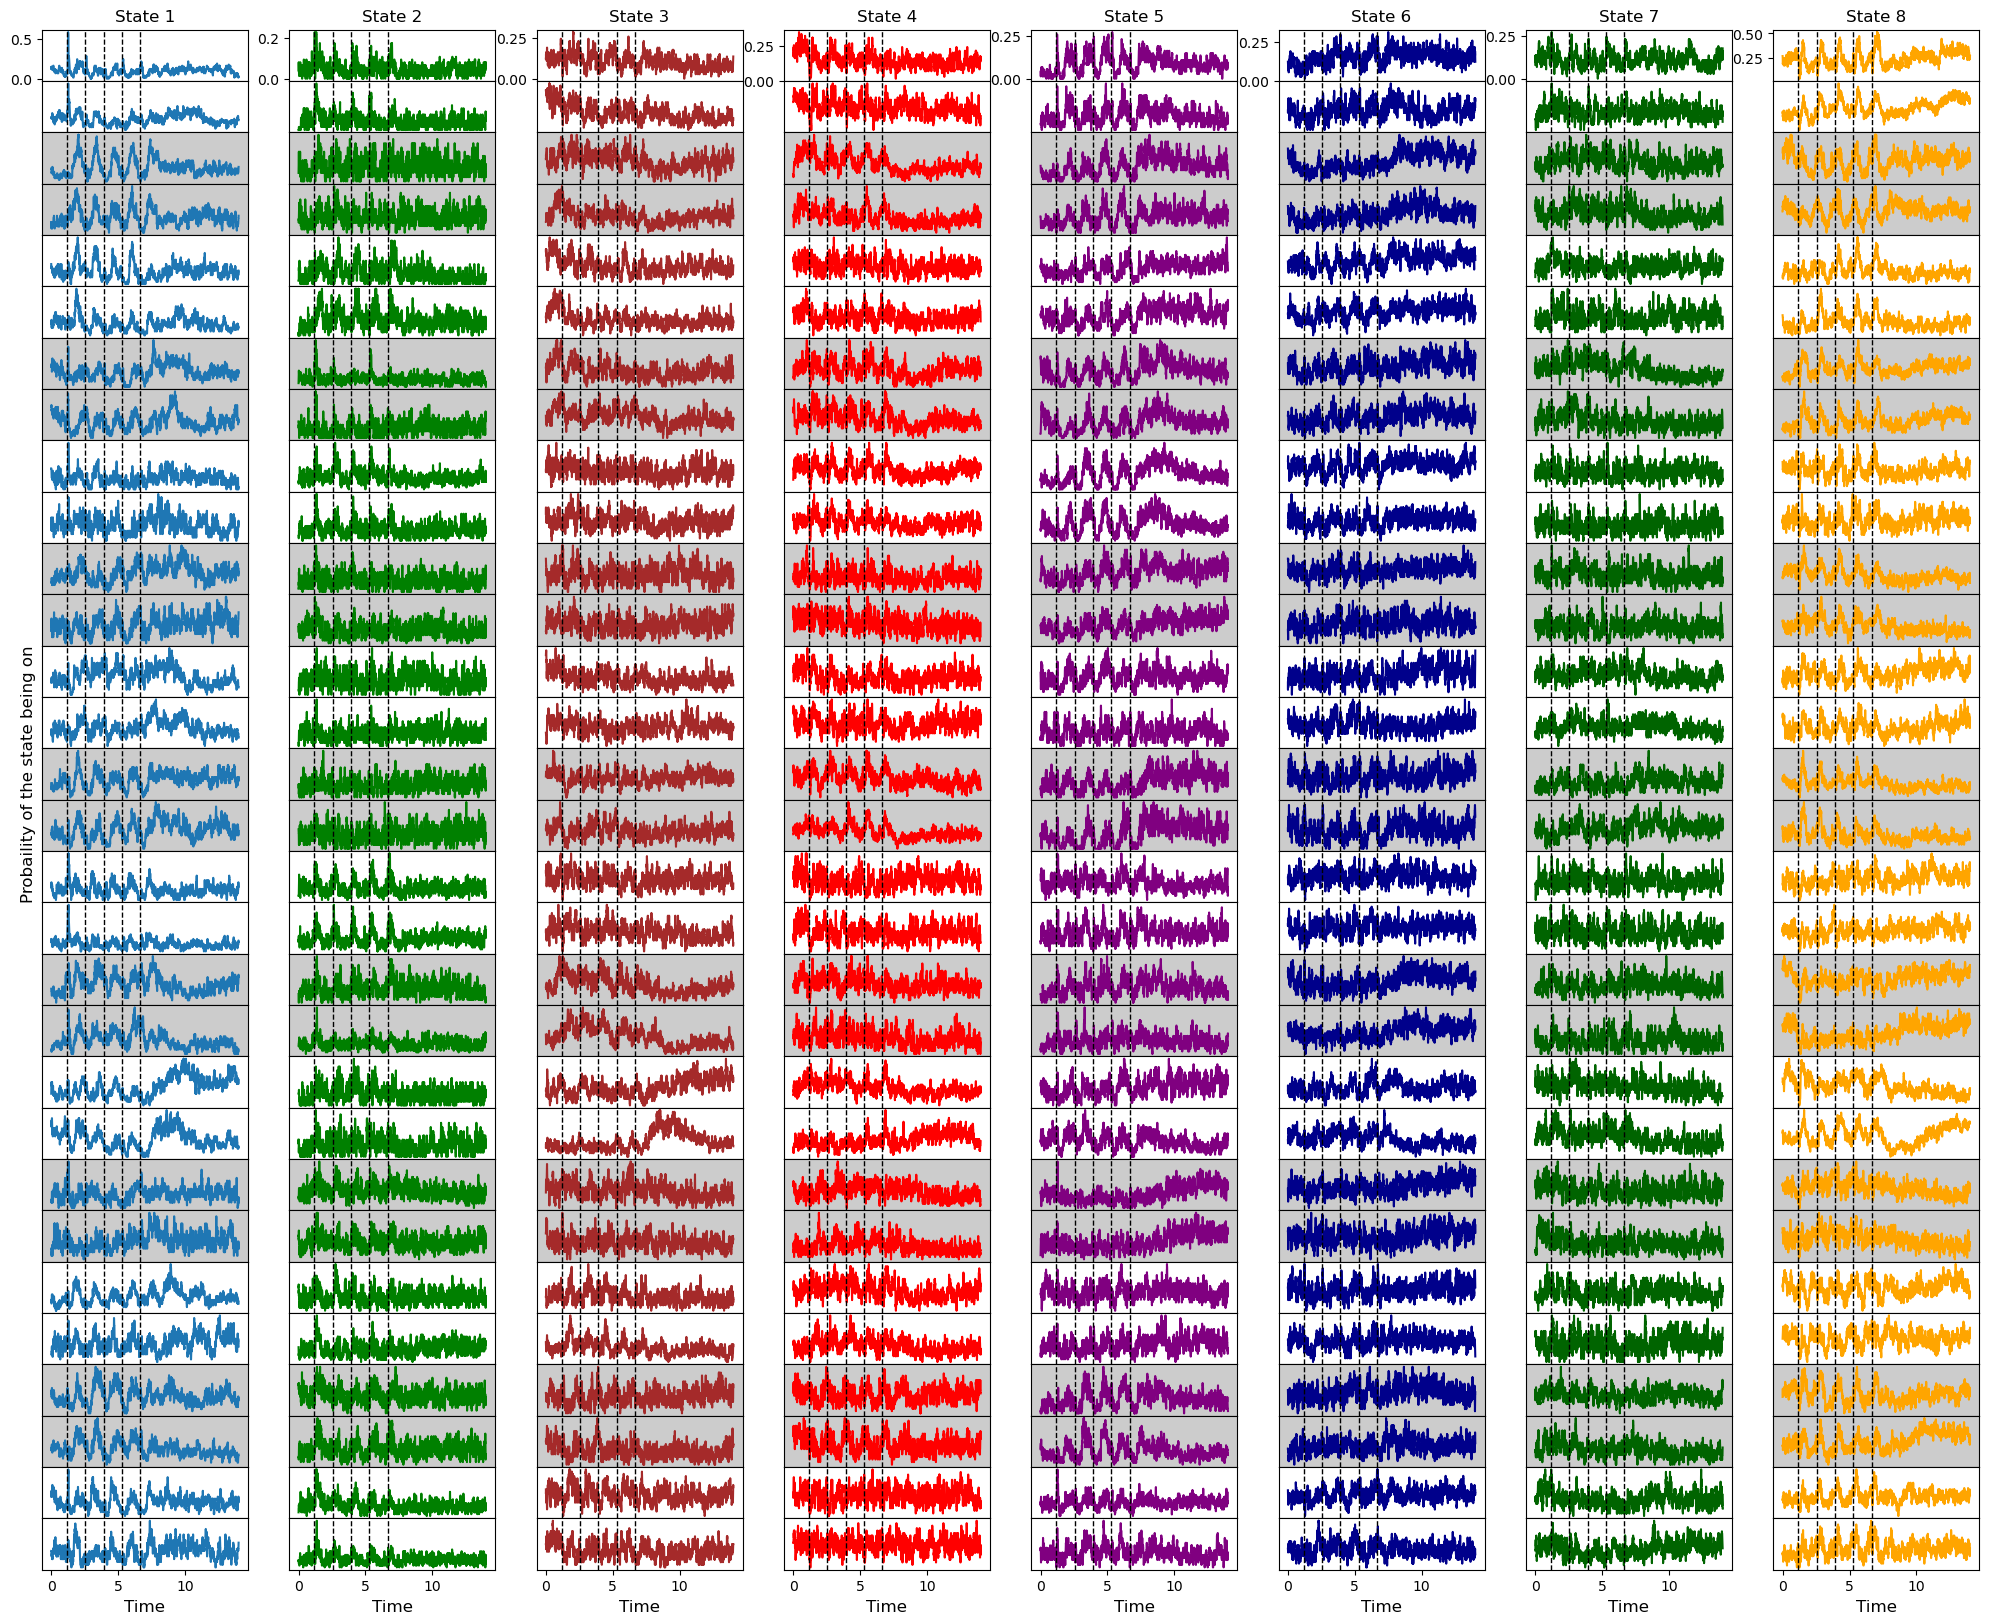

In [6]:
#PLOTTING SQUID STATE TRIAL TIMECOURSES
no_sessions = 30
fig, axs = plt.subplots(no_sessions, 8) #, sharey=True)
fig.set_size_inches(25,20)
fig.subplots_adjust(hspace=0)
 
time = np.linspace(0, 14, 3501)
 
for ses in range(0, no_sessions):
    axs[ses, 0].plot(time,alp_meaned_list_SQUID[ses][:,0])
    axs[ses, 1].plot(time,alp_meaned_list_SQUID[ses][:,1], 'g')
    axs[ses, 2].plot(time,alp_meaned_list_SQUID[ses][:,2], 'brown')
    axs[ses, 3].plot(time,alp_meaned_list_SQUID[ses][:,3], 'r')
    axs[ses, 4].plot(time,alp_meaned_list_SQUID[ses][:,4], 'purple')
    axs[ses, 5].plot(time,alp_meaned_list_SQUID[ses][:,5], 'darkblue')
    axs[ses, 6].plot(time,alp_meaned_list_SQUID[ses][:,6], 'darkgreen')
    axs[ses, 7].plot(time,alp_meaned_list_SQUID[ses][:,7], 'orange')
 
#times where you want vertical dashed lines
vlines_times = [1.17, 2.54, 3.91, 5.28, 6.65]
 
for col in range(0,8):
    for row, ax in enumerate(axs[:, col]):
        for t in vlines_times:
            ax.axvline(
                x=t,
                color='black',
                linestyle='--',
                linewidth=1  # thin line
            )
 
        if row != 0:
                ax.tick_params(labelleft=False)
                ax.set_yticks([])
        if row == 14 and col == 0:
             ax.set_ylabel('Probaility of the state being on', size = 'large')
       
        if row == 0:
             ax.set_title('State ' + str(col + 1))
       
        if row == 29:
             ax.set_xlabel('Time', size='large')
   
for row in range(no_sessions):
    # integer divide by 2 → row pairs (0–1, 2–3, 4–5, ...)
    # % 2 toggles every pair
    if (row // 2) % 2 == 1:
        for col in range(8):
            axs[row, col].set_facecolor('0.80')  # light grey

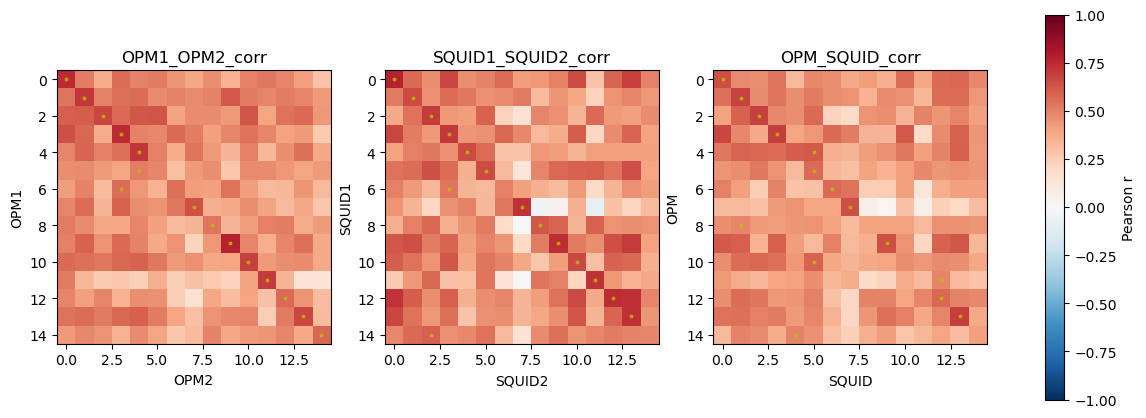

In [12]:
#CALCULATE AND PLOT CORRELATION COEFFCIENTS FOR TRIAL TIMECOUSRES
OPM_1 = alp_meaned_list[::2]
OPM_2 = alp_meaned_list[1::2]
SQUID_1 = alp_meaned_list_SQUID[::2]
SQUID_2 = alp_meaned_list_SQUID[1::2]

OPM1_OPM2_corr = np.zeros((15,15))
SQUID1_SQUID2_corr = np.zeros((15,15))
OPM_SQUID_corr = np.zeros((15,15))

for row in range(15):
    for colomn in range(15):
            OPM1_OPM2_corr[row,colomn] = scipy.stats.pearsonr(OPM_1[row].T.flatten(),OPM_2[colomn].T.flatten())[0]
            SQUID1_SQUID2_corr[row,colomn] = scipy.stats.pearsonr(SQUID_1[row].T.flatten(),SQUID_2[colomn].T.flatten())[0]
        
            OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM_1[row].T.flatten(),SQUID_1[colomn].T.flatten())[0]
            OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM_1[row].T.flatten(),SQUID_2[colomn].T.flatten())[0]
            OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM_2[row].T.flatten(),SQUID_1[colomn].T.flatten())[0]
            OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM_2[row].T.flatten(),SQUID_2[colomn].T.flatten())[0]

            OPM_SQUID_corr[row,colomn] = np.mean((OPM1_SQUID1_corr, OPM1_SQUID2_corr, OPM2_SQUID1_corr, OPM2_SQUID2_corr))
            OPM_SQUID_corr[row,colomn] = OPM2_SQUID2_corr

#PLOTTING 
mats = [OPM1_OPM2_corr, SQUID1_SQUID2_corr, OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['OPM1_OPM2_corr', 'SQUID1_SQUID2_corr', 'OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # mark row-wise maxima
    n_rows = mat.shape[0]
    for i in range(n_rows):
        j_max = np.argmax(mat[i, :])
        ax.scatter(j_max, i, color='y', marker='.', s=2, linewidths=2)

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

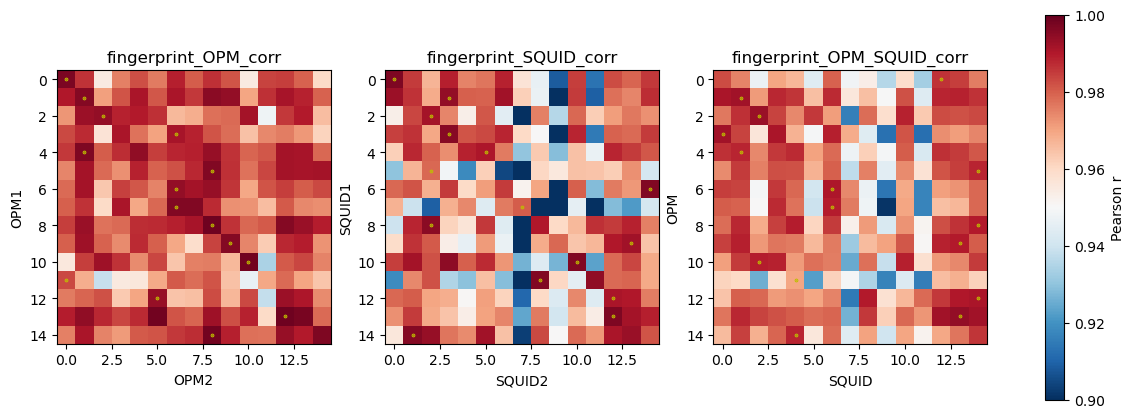

In [8]:
#CALCULATING AND PLOTTING COEFFCIENTS FOR SUMMARY STATS 

#IMPORTING SUMMARY STATS 
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
hmm_dir_opms = f"{deriv}/hmm_8state_opms"
hmm_dir_squids = f"{deriv}/hmm_8state_squids"

fo_SQUID = np.load(f'{hmm_dir_squids}/summary_stats/fo.npy')
lt_SQUID = np.load(f'{hmm_dir_squids}/summary_stats/lt.npy')
intv_SQUID = np.load(f'{hmm_dir_squids}/summary_stats/intv.npy')
sr_SQUID = np.load(f'{hmm_dir_squids}/summary_stats/sr.npy')

fo_OPM = np.load(f'{hmm_dir_opms}/summary_stats/fo.npy')
lt_OPM = np.load(f'{hmm_dir_opms}/summary_stats/lt.npy')
intv_OPM = np.load(f'{hmm_dir_opms}/summary_stats/intv.npy')
sr_OPM = np.load(f'{hmm_dir_opms}/summary_stats/sr.npy')

fingerprint_OPM = np.zeros((30,4,8))
fingerprint_SQUID = np.zeros((30,4,8))

for ses in range(30):
    fingerprint_array_SQUID = fingerprint_SQUID[ses]
    fingerprint_array_OPM = fingerprint_OPM[ses]

    fingerprint_array_SQUID[0] = fo_SQUID[ses]
    fingerprint_array_SQUID[1] = lt_SQUID[ses]
    fingerprint_array_SQUID[2] = intv_SQUID[ses]
    fingerprint_array_SQUID[3] = sr_SQUID[ses]
    fingerprint_SQUID[ses] = fingerprint_array_SQUID

    fingerprint_array_OPM[0] = fo_OPM[ses]
    fingerprint_array_OPM[1] = lt_OPM[ses]
    fingerprint_array_OPM[2] = intv_OPM[ses]
    fingerprint_array_OPM[3] = sr_OPM[ses]
    fingerprint_OPM[ses] = fingerprint_array_OPM

OPM1_fingerprints = fingerprint_OPM[::2]
OPM2_fingerprints = fingerprint_OPM[1::2]
SQUID1_fingerprints = fingerprint_SQUID[::2]
SQUID2_fingerprints = fingerprint_SQUID[1::2]

#CALCULATING COEFFCIENTS 
fingerprint_OPM_corr = np.zeros((15,15))
fingerprint_SQUID_corr = np.zeros((15,15))
fingerprint_OPM_SQUID_corr = np.zeros((15,15))

for row in range(15):
    for colomn in range(15):
        fingerprint_OPM_corr[row,colomn] = scipy.stats.pearsonr(OPM1_fingerprints[row].flatten(),OPM2_fingerprints[colomn].flatten())[0]
        fingerprint_SQUID_corr[row,colomn] = scipy.stats.pearsonr(SQUID1_fingerprints[row].flatten(),SQUID2_fingerprints[colomn].flatten())[0]

        fingerprint_OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM1_fingerprints[row].flatten(),SQUID1_fingerprints[colomn].flatten())[0]
        fingerprint_OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM1_fingerprints[row].flatten(),SQUID2_fingerprints[colomn].flatten())[0]
        fingerprint_OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM2_fingerprints[row].flatten(),SQUID1_fingerprints[colomn].flatten())[0]
        fingerprint_OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM2_fingerprints[row].flatten(),SQUID2_fingerprints[colomn].flatten())[0]

        fingerprint_OPM_SQUID_corr[row,colomn] = np.mean((fingerprint_OPM1_SQUID1_corr, fingerprint_OPM1_SQUID2_corr, fingerprint_OPM2_SQUID1_corr, fingerprint_OPM2_SQUID2_corr))

#PLOTTING 
mats = [fingerprint_OPM_corr, fingerprint_SQUID_corr, fingerprint_OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['fingerprint_OPM_corr', 'fingerprint_SQUID_corr', 'fingerprint_OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=0.9, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # mark row-wise maxima
    n_rows = mat.shape[0]
    for i in range(n_rows):
        j_max = np.argmax(mat[i, :])
        ax.scatter(j_max, i, color='y', marker='.', s=2, linewidths=2)

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

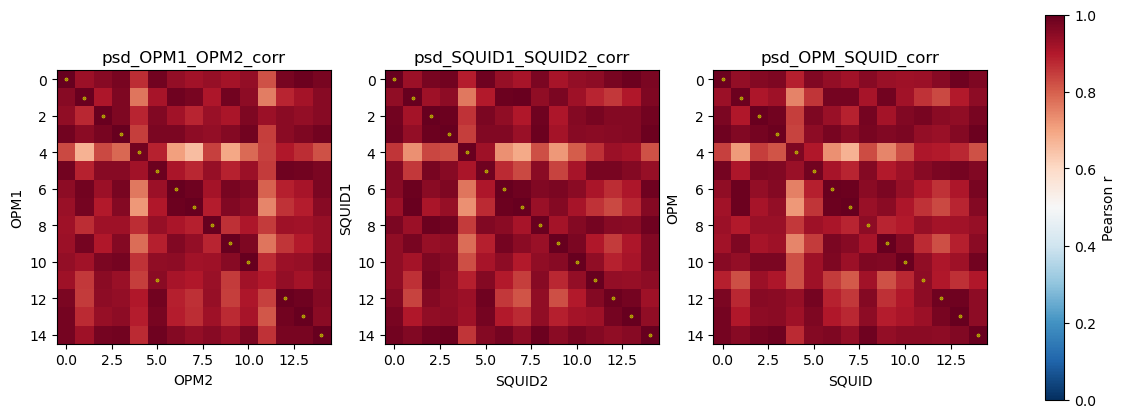

In [16]:
#CALCULATING AND PLOTTING COEFFCIENTS FOR STATE PSDS

#IMPORTING PSD ARRAYS 
f = np.load(f'{hmm_dir_opms}/summary_stats/f.npy')
psd = np.load(f'{hmm_dir_opms}/summary_stats/psd.npy')

f_SQUID = np.load(f'{hmm_dir_squids}/summary_stats/f.npy')
psd_SQUID = np.load(f'{hmm_dir_squids}/summary_stats/psd.npy')

#CALCULATING COEFFCIENTS FOR STATE PSDS
OPM_1_psd = psd[::2]
OPM_1_psd = np.mean(OPM_1_psd, axis=2)
OPM_2_psd = psd[1::2]
OPM_2_psd = np.mean(OPM_2_psd, axis=2)
SQUID_1_psd = psd_SQUID[::2]
SQUID_1_psd = np.mean(SQUID_1_psd, axis=2)
SQUID_2_psd = psd_SQUID[1::2]
SQUID_2_psd = np.mean(SQUID_2_psd, axis=2)

psd_OPM1_OPM2_corr = np.zeros((15,15))
psd_SQUID1_SQUID2_corr = np.zeros((15,15))
psd_OPM_SQUID_corr = np.zeros((15,15))

for row in range(15):
    for colomn in range(15):
            psd_OPM1_OPM2_corr[row,colomn] = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),OPM_2_psd[colomn].ravel())[0]
            psd_SQUID1_SQUID2_corr[row,colomn] = scipy.stats.pearsonr(SQUID_1_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]
        
            psd_OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),SQUID_1_psd[colomn].ravel())[0]
            psd_OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]
            psd_OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM_2_psd[row].ravel(),SQUID_1_psd[colomn].ravel())[0]
            psd_OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM_2_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]

            psd_OPM_SQUID_corr[row,colomn] = np.mean((psd_OPM1_SQUID1_corr, psd_OPM1_SQUID2_corr, psd_OPM2_SQUID1_corr, psd_OPM2_SQUID2_corr))


#PLOTTING 
mats = [psd_OPM1_OPM2_corr, psd_SQUID1_SQUID2_corr, psd_OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=0, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # mark row-wise maxima
    n_rows = mat.shape[0]
    for i in range(n_rows):
        j_max = np.argmax(mat[i, :])
        ax.scatter(j_max, i, color='y', marker='.', s=2, linewidths=2)

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

In [2]:
#STATE TRANSITION PROBABILITY CORRELATION COEFFCIENTS